# Análisis exploratorio de una base de datos de películas

Usa la base de datos `./data/imdb.csv`


### 1. Importar `pandas`, `matplotlib` y `numpy`

In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### 2. Leer la base de datos del archivo csv a pandas

In [46]:
bd = pd.read_csv('/home/edaxisrosnez/HYBRIDGE/limpieza_datos_y_eda_EARJ/data/imdb.csv',
                 encoding='ISO-8859-1')

### 3. Mostrar las  primeras y últimas filas del dataframe. Hacerlo con el valor default y pasando como argumento el número entero de filas que se deseen inspeccionar.

In [35]:
bd.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [36]:
bd.tail()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


In [37]:
bd.head(1) 

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0


In [38]:
bd.tail(1)

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
999,1000,Nine Lives,"Comedy,Family,Fantasy",A stuffy businessman finds himself trapped ins...,Barry Sonnenfeld,"Kevin Spacey, Jennifer Garner, Robbie Amell,Ch...",2016,87,5.3,12435,19.64,11.0


### 4. Continúa inspeccionando el archivo viendo todas las columnas del dataframe

In [39]:
bd.columns.to_list()

['Rank',
 'Title',
 'Genre',
 'Description',
 'Director',
 'Actors',
 'Year',
 'Runtime (Minutes)',
 'Rating',
 'Votes',
 'Revenue (Millions)',
 'Metascore']

### 5. Imprime los primeros valores de la variable `Rank`

In [41]:
bd["Rank"][0:5]
bd["Rank"].head()

0    1
1    2
2    3
3    4
4    5
Name: Rank, dtype: int64

### 6. Demuestra que es mejor tener nombres de columnas sin espacios (notación corchetes y notación punto-variable).

La siguiente línea de código muestra un error porque el nombre de la columna tiene un espacio y, por consiguiente, hace que el espacio python lo trate de interpretar como si esperara una variable o algún comando más.

In [51]:
bd["Runtime (Minutes)"]
bd.Runtime (Minutes)

0      121
1      124
2      117
3      108
4      123
      ... 
995    111
996     94
997     98
998     93
999     87
Name: Runtime (Minutes), Length: 1000, dtype: int64

Sin embargo, si cambiamos ponemos el nombre en formato snake_case, lo anterior se podrá hacer sin problema alguno.

In [52]:
bd2 = bd
bd = bd.rename(columns = {"Runtime (Minutes)": "Runtime_minutes"})
bd.Runtime_minutes

0      121
1      124
2      117
3      108
4      123
      ... 
995    111
996     94
997     98
998     93
999     87
Name: Runtime_minutes, Length: 1000, dtype: int64

Aunque, incluso teniendo espacios, se podrían mostrar las columnas deseadas accediendo a ellas por medio de corchetes.

In [54]:
# Las dos siguientes líneas hacen lo mismo
bd2["Runtime (Minutes)"]
bd["Runtime_minutes"]

0      121
1      124
2      117
3      108
4      123
      ... 
995    111
996     94
997     98
998     93
999     87
Name: Runtime_minutes, Length: 1000, dtype: int64

### 7. Renombra las columnas que tengan espacios

Se reutilizará el código que vimos en `1_limpieza_de_datos`

In [65]:
def limpiar_columnas(df:pd.DataFrame):
    columnas_limpias = []
    for col in df.columns:
        # convertir a minusculas, reemplazar espacios por guiones bajos y eliminar caracteres especiales
        col = col.lower().replace(" ", "_").replace("ñ", "ni").replace(".", "").replace("á", "a").replace("é", "e").replace("í","i").replace("ó", "o").replace("ú", "u").replace("(", "").replace(")", "")
        columnas_limpias.append(col)
    
    df.columns = columnas_limpias
    
    return df

In [66]:
bd = limpiar_columnas(bd)
bd.sample(3)

,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
5,6,The Great Wall,"Action,Adventure,Fantasy",European mercenaries searching for black powde...,Yimou Zhang,"Matt Damon, Tian Jing, Willem Dafoe, Andy Lau",2016,103,6.1,56036,45.13,42.0
114,115,Harry Potter and the Deathly Hallows: Part 2,"Adventure,Drama,Fantasy","Harry, Ron and Hermione search for Voldemort's...",David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, M...",2011,130,8.1,590595,380.96,87.0
197,198,Into the Wild,"Adventure,Biography,Drama","After graduating from Emory University, top st...",Sean Penn,"Emile Hirsch, Vince Vaughn, Catherine Keener, ...",2007,148,8.1,459304,18.35,73.0


### 8. Utiliza tus nuevas columnas sin espacios :)

In [67]:
bd[["runtime_minutes", "revenue_millions"]]

,runtime_minutes,revenue_millions
0,121,333.13
1,124,126.46
2,117,138.12
3,108,270.32
4,123,325.02
...,...,...
995,111,NaN
996,94,17.54
997,98,58.01
998,93,NaN


### 9. Visualiza la info de todo tu dataframe

In [62]:
bd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rank                1000 non-null   int64  
 1   title               1000 non-null   object 
 2   genre               1000 non-null   object 
 3   description         1000 non-null   object 
 4   director            1000 non-null   object 
 5   actors              1000 non-null   object 
 6   year                1000 non-null   int64  
 7   runtime_minutes     1000 non-null   int64  
 8   rating              1000 non-null   float64
 9   votes               1000 non-null   int64  
 10  revenue_(millions)  872 non-null    float64
 11  metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


### 10. Inspecciona si hay columnas que tengan valores `NA`

En este punto tuve que modificar la limpieza de los nombres debido a que los paréntesis tampoco son admitidos.

In [91]:
bd.columns.to_list()
bd_isna = bd[['rank', 'title', 'genre',
 'description', 'director', 'actors',
 'year', 'runtime_minutes', 'rating',
 'votes', 'revenue_millions', 'metascore']].isna()
bd_isna.any()

rank                False
title               False
genre               False
description         False
director            False
actors              False
year                False
runtime_minutes     False
rating              False
votes               False
revenue_millions     True
metascore            True
dtype: bool

Podemos ver que las únicas columnas que contienen valores NA son los de revenue_millions y metascore.

### 11. Imprime el número total de valores NA que haya en cada columna. Hazlo primero para la columna `Metascore` y después utiliza un ciclo for para hacerlo para todas las columnas

Primero lo hice como lo entendí.

In [104]:
type(bd_isna.sum())
bd_isna.sum()

rank                  0
title                 0
genre                 0
description           0
director              0
actors                0
year                  0
runtime_minutes       0
rating                0
votes                 0
revenue_millions    128
metascore            64
dtype: int64

Ahora lo haré como creo que es al volver a leer la instrucción.

In [105]:
bd_isna.metascore.sum()

np.int64(64)

In [115]:
for col in bd_isna.columns.to_list():
    print(f"{col} tiene", bd_isna[col].sum(), " valores NA") #´     

rank tiene 0  valores NA
title tiene 0  valores NA
genre tiene 0  valores NA
description tiene 0  valores NA
director tiene 0  valores NA
actors tiene 0  valores NA
year tiene 0  valores NA
runtime_minutes tiene 0  valores NA
rating tiene 0  valores NA
votes tiene 0  valores NA
revenue_millions tiene 128  valores NA
metascore tiene 64  valores NA


En la segunda dimensión de la serie anterior se observa el número de valores NA en el cada una de las dimensiones del dataframe con el que estamos trabajando.

### 12. Usa la magia de `dropna()`

In [116]:
bd = bd.dropna()

### 13. Vuelve a ver la info del dataset

In [118]:
bd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 838 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              838 non-null    int64  
 1   title             838 non-null    object 
 2   genre             838 non-null    object 
 3   description       838 non-null    object 
 4   director          838 non-null    object 
 5   actors            838 non-null    object 
 6   year              838 non-null    int64  
 7   runtime_minutes   838 non-null    int64  
 8   rating            838 non-null    float64
 9   votes             838 non-null    int64  
 10  revenue_millions  838 non-null    float64
 11  metascore         838 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 85.1+ KB


### 14. Genera estadísticos descriptivos con el método `describe()`

In [119]:
bd.describe()

,rank,year,runtime_minutes,rating,votes,revenue_millions,metascore
count,838.000000,838.00000,838.000000,838.000000,8.380000e+02,838.000000,838.000000
mean,485.247017,2012.50716,114.638425,6.814320,1.932303e+05,84.564558,59.575179
std,286.572065,3.17236,18.470922,0.877754,1.930990e+05,104.520227,16.952416
min,1.000000,2006.00000,66.000000,1.900000,1.780000e+02,0.000000,11.000000
25%,238.250000,2010.00000,101.000000,6.300000,6.127650e+04,13.967500,47.000000
50%,475.500000,2013.00000,112.000000,6.900000,1.368795e+05,48.150000,60.000000
75%,729.750000,2015.00000,124.000000,7.500000,2.710830e+05,116.800000,72.000000
max,1000.000000,2016.00000,187.000000,9.000000,1.791916e+06,936.630000,100.000000


### 15. Crea un histograma de la variable Metascore. Utiliza 10 cubetas

Para esto contaremos cada valor de metascore con el método `value_counts()`, de esta manera podremos saber qué tantas veces se repite cada valor.
Posteriormente, ordenaremos esos valores para que el eje X sea congruente.

In [ ]:
counts = bd.metascore.value_counts()
counts_df = pd.DataFrame({'metascore' : counts.index, 'frecuencia' : counts.values})
counts_df = counts_df.sort_values(['metascore'])
# plt.bar(counts_df.metascore, counts_df.frecuencia)

Finalmente, utilizamos `hist()` con 10 cubetas para la visualización de estos datos.

(array([  6.,  18.,  73.,  98., 140., 158., 150., 125.,  53.,  17.]),
 array([ 11. ,  19.9,  28.8,  37.7,  46.6,  55.5,  64.4,  73.3,  82.2,
         91.1, 100. ]),
 <BarContainer object of 10 artists>)

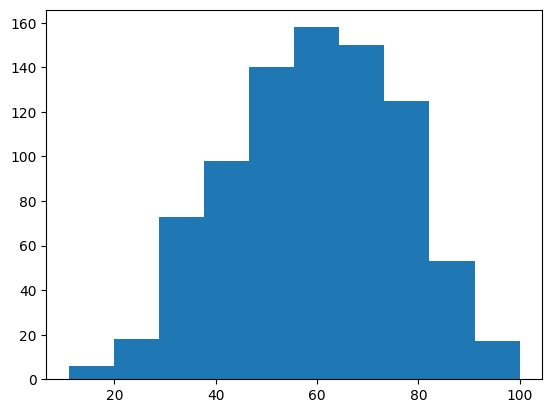

In [139]:
plt.hist(bd.metascore, 10)

### 16. Crea un histograma de la variable Rating. Utiliza 10 cubetas

(array([1., 1., 2., 5., 7., 7., 7., 7., 7., 6.]),
 array([1.9 , 2.61, 3.32, 4.03, 4.74, 5.45, 6.16, 6.87, 7.58, 8.29, 9.  ]),
 <BarContainer object of 10 artists>)

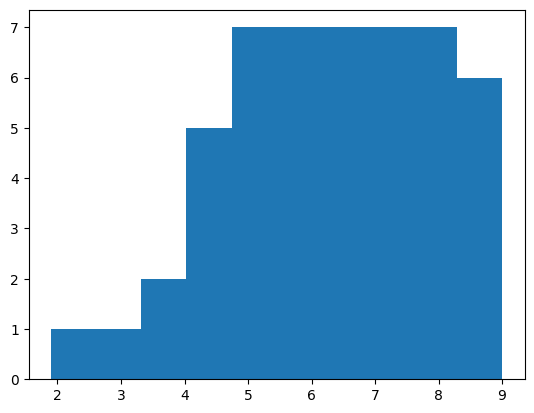

In [ ]:
counts_rating_bd = bd.rating.value_counts()
counts_rating_bd = pd.DataFrame({'rating' : counts_rating_bd.index, 'frecuencia' : counts_rating_bd.values})
counts_rating_bd = counts_rating_bd.sort_values(['rating'])
plt.hist(counts_rating_bd.rating, 10)

### 17. Vuelve a describir el dataframe y observa la media de la variable `Ratings`

In [150]:
bd.describe()

,rank,year,runtime_minutes,rating,votes,revenue_millions,metascore
count,838.000000,838.00000,838.000000,838.000000,8.380000e+02,838.000000,838.000000
mean,485.247017,2012.50716,114.638425,6.814320,1.932303e+05,84.564558,59.575179
std,286.572065,3.17236,18.470922,0.877754,1.930990e+05,104.520227,16.952416
min,1.000000,2006.00000,66.000000,1.900000,1.780000e+02,0.000000,11.000000
25%,238.250000,2010.00000,101.000000,6.300000,6.127650e+04,13.967500,47.000000
50%,475.500000,2013.00000,112.000000,6.900000,1.368795e+05,48.150000,60.000000
75%,729.750000,2015.00000,124.000000,7.500000,2.710830e+05,116.800000,72.000000
max,1000.000000,2016.00000,187.000000,9.000000,1.791916e+06,936.630000,100.000000


### 18. Calcula este promedio con Numpy y después con un método de Pandas

In [152]:
# Con numpy
np.array(bd.rating).mean()

np.float64(6.814319809069212)

In [153]:
# Con pandas
bd.rating.mean()

np.float64(6.814319809069212)

### 19. Obten los valores únicos de la variable Rating y después ordénalos de menor a mayor

In [174]:
unicos_rating = bd.rating.unique()
np.sort(unicos_rating)

array([1.9, 2.7, 3.9, 4. , 4.1, 4.3, 4.4, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
       5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4,
       6.5, 6.6, 6.7, 6.8, 6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7,
       7.8, 7.9, 8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.8, 9. ])

### 20. Observa los ratings que te interesen y ahora filtra el dataframe con ese rating para ver cuáles son las películas con dicho rating

In [181]:
rating_7a9 = bd[(bd.rating == 7) | (bd.rating == 8.8)]
rating_7a9.sample(10)

,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
524,525,Trust,"Crime,Drama,Thriller",A teenage girl is targeted by an online sexual...,David Schwimmer,"Clive Owen, Catherine Keener, Liana Liberato,J...",2010,106,7.0,36043,0.06,60.0
701,702,Ted,"Comedy,Fantasy","John Bennett, a man whose childhood wish of br...",Seth MacFarlane,"Mark Wahlberg, Mila Kunis, Seth MacFarlane, Jo...",2012,106,7.0,494641,218.63,62.0
85,86,Jurassic World,"Action,Adventure,Sci-Fi","A new theme park, built on the original site o...",Colin Trevorrow,"Chris Pratt, Bryce Dallas Howard, Ty Simpkins,...",2015,124,7.0,455169,652.18,59.0
80,81,Inception,"Action,Adventure,Sci-Fi","A thief, who steals corporate secrets through ...",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellen...",2010,148,8.8,1583625,292.57,74.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
432,433,World War Z,"Action,Adventure,Horror",Former United Nations employee Gerry Lane trav...,Marc Forster,"Brad Pitt, Mireille Enos, Daniella Kertesz, Ja...",2013,116,7.0,494819,202.35,63.0
875,876,28 Weeks Later,"Drama,Horror,Sci-Fi",Six months after the rage virus was inflicted ...,Juan Carlos Fresnadillo,"Jeremy Renner, Rose Byrne, Robert Carlyle, Har...",2007,100,7.0,221858,28.64,78.0
182,183,Cinderella,"Drama,Family,Fantasy","When her father unexpectedly passes away, youn...",Kenneth Branagh,"Lily James, Cate Blanchett, Richard Madden,Hel...",2015,105,7.0,117018,201.15,67.0
368,369,The Amazing Spider-Man,"Action,Adventure",After Peter Parker is bitten by a genetically ...,Marc Webb,"Andrew Garfield, Emma Stone, Rhys Ifans, Irrfa...",2012,136,7.0,474320,262.03,66.0
873,874,One Day,"Drama,Romance",After spending the night together on the night...,Lone Scherfig,"Anne Hathaway, Jim Sturgess, Patricia Clarkson...",2011,107,7.0,113599,13.77,48.0


### 21. Obten los valores únicos de la variable Rating y la frecuencia total de cada uno de estos valores. Posteriormente crea un nuevo dataframe con esos valores

In [193]:
counts_rating_bd = bd.rating.value_counts()
counts_rating_bd = pd.DataFrame({'rating' : counts_rating_bd.index, 
                                 'frecuencia' : counts_rating_bd.values})
counts_rating_bd

,rating,frecuencia
0,7.0,43
1,6.7,42
2,7.1,40
3,7.8,38
4,7.2,38
5,6.6,37
6,7.3,37
7,6.3,36
8,6.5,35
9,6.2,33


### 22. Ordena el nuevo dataframe por la variable `rating`

In [194]:
counts_rating_bd = counts_rating_bd.sort_values(['rating'])
counts_rating_bd

,rating,frecuencia
46,1.9,1
47,2.7,1
38,3.9,2
45,4.0,1
43,4.1,1
36,4.3,3
48,4.4,1
39,4.6,2
35,4.7,3
49,4.8,1


### 23. Crea una gráfica de barras con este nuevo dataframe ordenado

<BarContainer object of 50 artists>

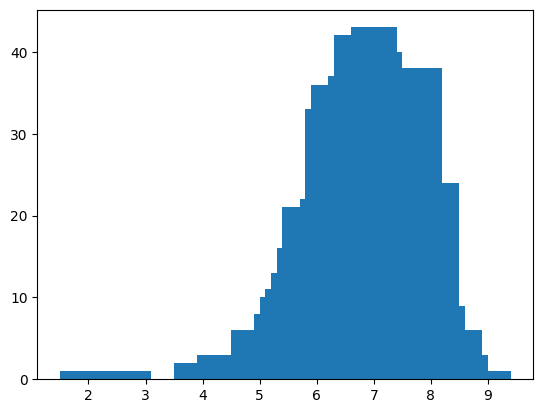

In [195]:
plt.bar(counts_rating_bd.rating, counts_rating_bd.frecuencia)

### 24. Crea la matriz de correlación del dataframe de películas

En este paso se quitaron las columnas que no tenían datos numéricos, ya que la correlación es un cálculo.

In [199]:
bd.columns.to_list()
bd_corr = bd[['rank',
#  'title',
#  'genre',
#  'description',
#  'director',
#  'actors',
 'year',
 'runtime_minutes',
 'rating',
 'votes',
 'revenue_millions',
 'metascore']].corr()
bd_corr


,rank,year,runtime_minutes,rating,votes,revenue_millions,metascore
rank,1.000000,-0.312809,-0.254783,-0.243125,-0.303284,-0.273170,-0.195909
year,-0.312809,1.000000,-0.101933,-0.145703,-0.362445,-0.129198,-0.062303
runtime_minutes,-0.254783,-0.101933,1.000000,0.374566,0.399298,0.281721,0.221397
rating,-0.243125,-0.145703,0.374566,1.000000,0.517452,0.217106,0.672731
votes,-0.303284,-0.362445,0.399298,0.517452,1.000000,0.636833,0.332674
revenue_millions,-0.273170,-0.129198,0.281721,0.217106,0.636833,1.000000,0.142397
metascore,-0.195909,-0.062303,0.221397,0.672731,0.332674,0.142397,1.000000


### 25. Grafica la matriz de correlación utilizando `matshow()`

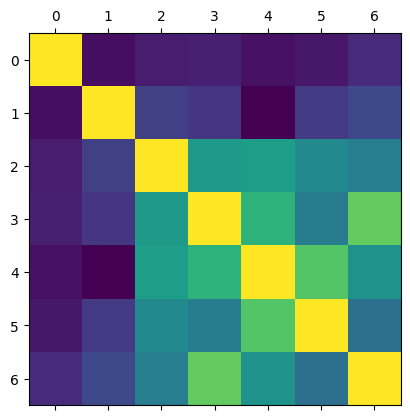

In [205]:
plt.matshow(bd_corr)